In [17]:
# PHASE 4 — BANK EDA
# Project: Cancel Culture — Customer Churn Analysis
# Dataset: Bank Customer Churn
# CELL 1 — IMPORT LIBRARIES AND LOAD CLEAN DATA
# Loads all tools and brings in the cleaned bank dataset
# ============================================================
 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
 
df = pd.read_csv('/Users/hinahaq/Downloads/Final_Project/clean_data/bank_churn_cleaned.csv')
project_path = '/Users/hinahaq/Downloads/Final_Project/clean_data/'
df = pd.read_csv(project_path + 'bank_churn_cleaned.csv')
 
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Churn rate: {df['Churn_Binary'].mean()*100:.1f}%")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
 
 

Data loaded: 10000 rows, 13 columns
Churn rate: 20.4%

Churn distribution:
Churn
No     7963
Yes    2037
Name: count, dtype: int64


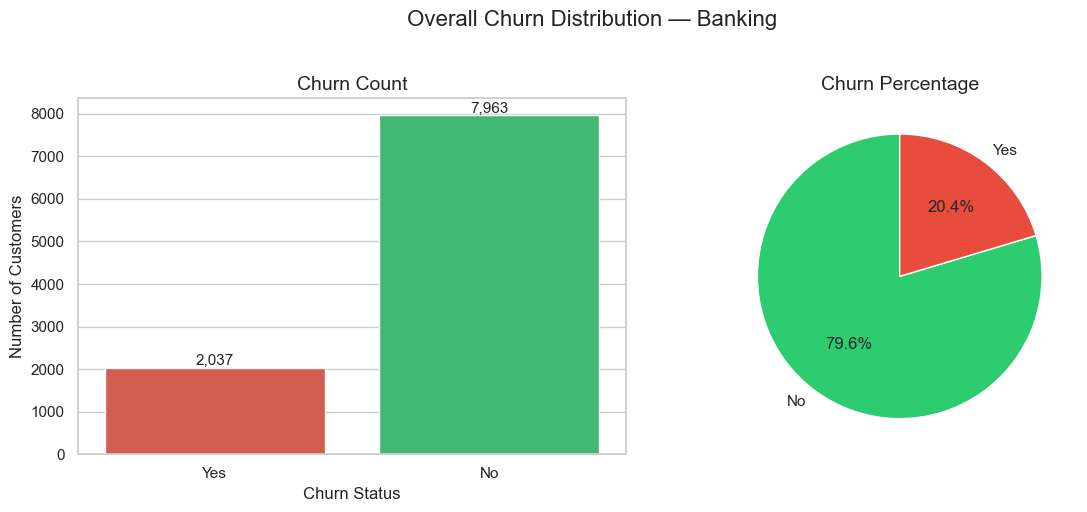

Cell 2 complete — Churn Distribution


In [5]:
# CELL 2 — OVERALL CHURN DISTRIBUTION
# Shows how many customers churned vs stayed
# First baseline — how big is the churn problem in banking?
# ============================================================
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Chart 1 — Count
sns.countplot(data=df, x='Churn', hue='Churn',
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              legend=False, ax=axes[0])
axes[0].set_title('Churn Count', fontsize=14)
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)
 
# Chart 2 — Pie
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14)
 
plt.suptitle('Overall Churn Distribution — Banking', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 2 complete — Churn Distribution")

**Overall Churn Distribution:
Banking churn rate is 20.4% — 2,037 out of 10,000 customers left. This is notably lower than Telco's 26.6%, suggesting banking customers have slightly more friction to switching.**

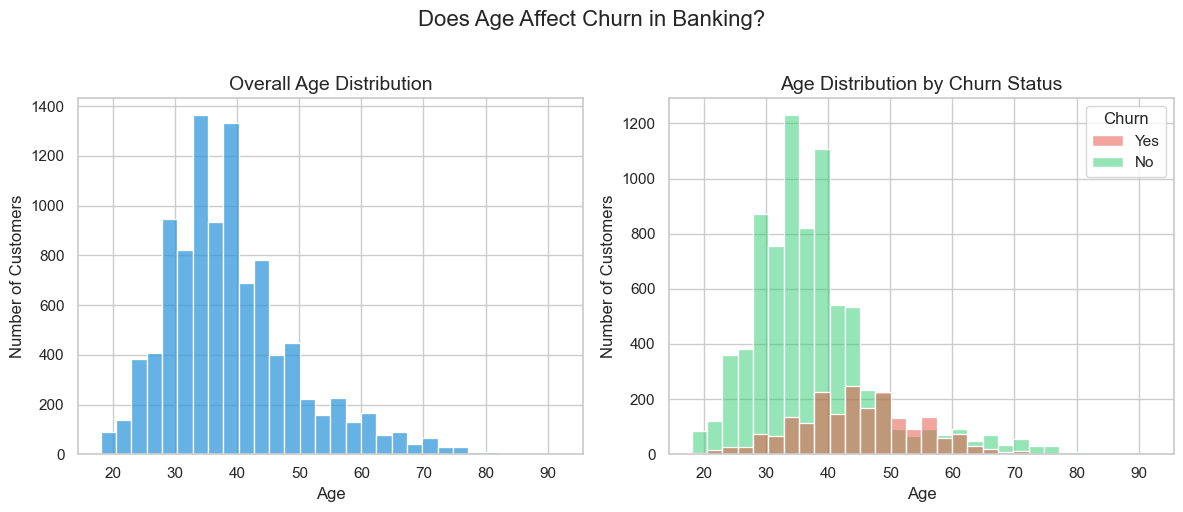

Cell 3 complete — Age Distribution


In [6]:
# CELL 3 — AGE DISTRIBUTION
# Banking churn is strongly driven by age unlike telecom
# ============================================================
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Chart 1 — Overall age distribution
sns.histplot(data=df, x='Age', bins=30,
             color='#3498db', ax=axes[0])
axes[0].set_title('Overall Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')
 
# Chart 2 — Age split by churn
sns.histplot(data=df, x='Age', hue='Churn',
             bins=30, palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
             ax=axes[1])
axes[1].set_title('Age Distribution by Churn Status', fontsize=14)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Customers')
 
plt.suptitle('Does Age Affect Churn in Banking?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_02_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 3 complete — Age Distribution")

**Age Distribution:
The right chart shows red bars (churners) concentrated between ages 40-60, while younger customers are predominantly green. Age is clearly a churn driver in banking in a way it is not in Telco.**

--- CHURN RATE BY AGE GROUP ---
  Age_Group  Churn_Rate
0     18-30    7.502569
1     31-40   12.087171
2     41-50   33.965517
3     51-60   56.210790
4       60+   24.784483


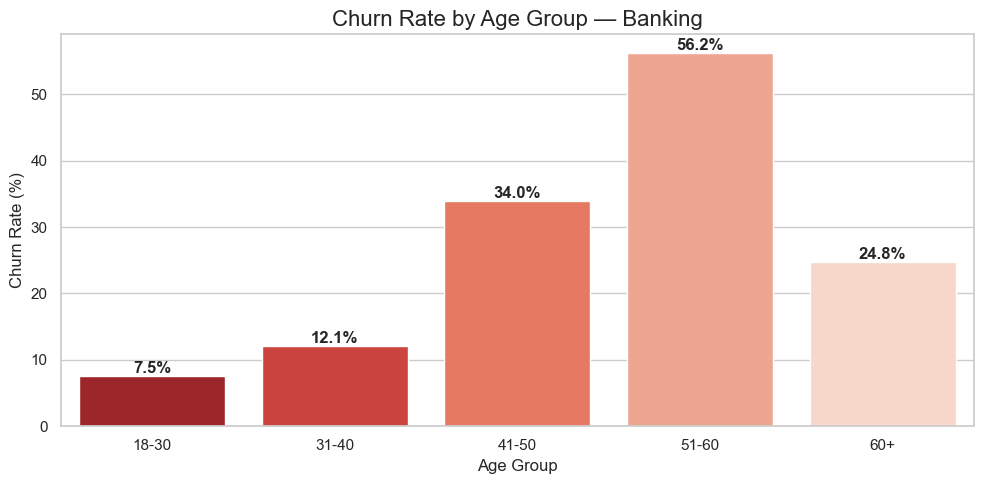

Cell 4 complete — Churn by Age Group


In [7]:
# CELL 4 — CHURN BY AGE GROUP
# Creates age groups to find which age bracket churns most
# ============================================================
 
# Create age groups
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[18, 30, 40, 50, 60, 92],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])
 
age_churn = df.groupby('Age_Group', observed=True)['Churn_Binary'].mean() * 100
age_churn = age_churn.reset_index()
age_churn.columns = ['Age_Group', 'Churn_Rate']
 
print("--- CHURN RATE BY AGE GROUP ---")
print(age_churn)
 
plt.figure(figsize=(10, 5))
bars = sns.barplot(data=age_churn, x='Age_Group', y='Churn_Rate',
                   hue='Age_Group', palette='Reds_r', legend=False)
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')
 
plt.title('Churn Rate by Age Group — Banking', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_03_churn_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 4 complete — Churn by Age Group")
 
 

**Churn by Age Group:
The 51-60 age group churns at 56.2% , the highest of any group. Middle-aged and older customers are the most at risk segment, which is the opposite pattern to Telco where new customers were the danger zone.**


--- CHURN RATE BY GEOGRAPHY ---
  Geography  Churn_Rate
1   Germany   32.443204
2     Spain   16.673395
0    France   16.154767


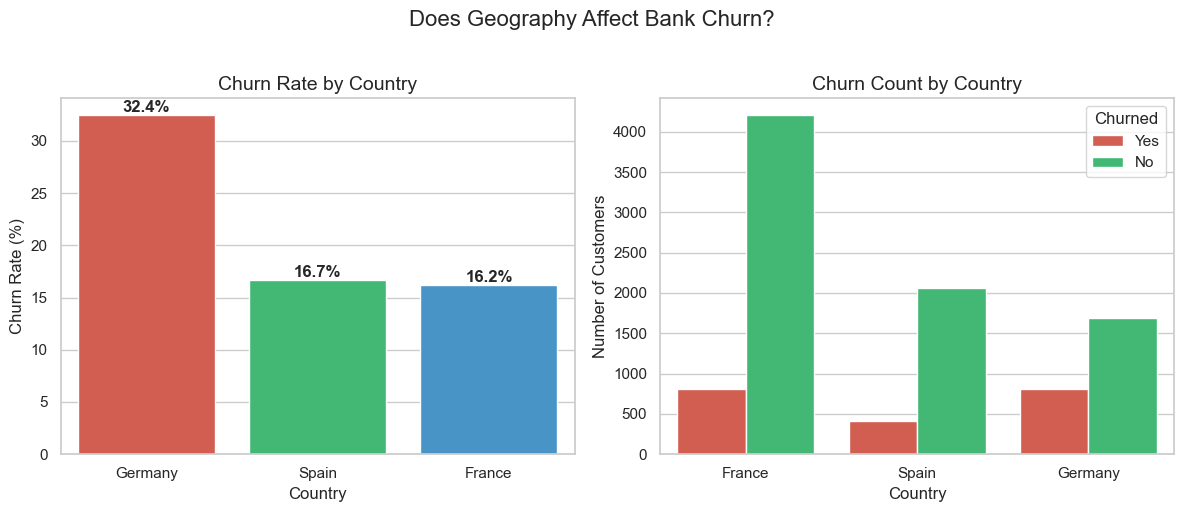

Cell 5 complete — Churn by Geography


In [8]:
# CELL 5 — CHURN BY GEOGRAPHY
# Banking dataset has France, Germany, Spain
# Does location affect churn? Germany tends to churn more
# This has no equivalent in Telco — unique to banking
# ============================================================
 
geo_churn = df.groupby('Geography')['Churn_Binary'].mean() * 100
geo_churn = geo_churn.reset_index()
geo_churn.columns = ['Geography', 'Churn_Rate']
geo_churn = geo_churn.sort_values('Churn_Rate', ascending=False)
 
print("--- CHURN RATE BY GEOGRAPHY ---")
print(geo_churn)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Chart 1 — Churn rate by country
bars = sns.barplot(data=geo_churn, x='Geography', y='Churn_Rate',
                   hue='Geography',
                   palette={'Germany': '#e74c3c',
                            'France': '#3498db',
                            'Spain': '#2ecc71'},
                   legend=False, ax=axes[0])
axes[0].set_title('Churn Rate by Country', fontsize=14)
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Churn Rate (%)')
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')
 
# Chart 2 — Customer count by country
sns.countplot(data=df, x='Geography', hue='Churn',
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              ax=axes[1])
axes[1].set_title('Churn Count by Country', fontsize=14)
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Churned')
 
plt.suptitle('Does Geography Affect Bank Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_04_churn_by_geography.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 5 complete — Churn by Geography")
 

**Churn by Geography:
Germany churns at 32.4% , double the rate of France (16.2%) and Spain (16.7%). Geography is a strong predictor of bank churn and has no equivalent in the Telco dataset.**

--- CHURN RATE BY NUMBER OF PRODUCTS ---
   NumOfProducts  Churn_Rate
0              1   27.714398
1              2    7.581699
2              3   82.706767
3              4  100.000000


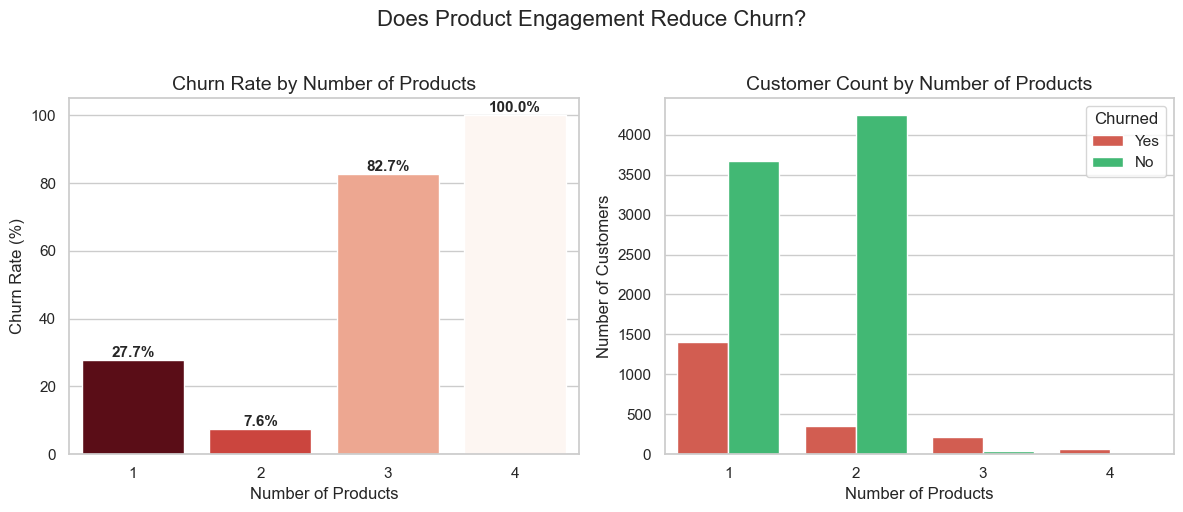

Cell 6 complete — Churn by Number of Products


In [9]:
# CELL 6 — CHURN BY NUMBER OF PRODUCTS
# How many bank products does a customer have?
# (savings account, credit card, loan etc.)
# More products = more engaged = less likely to leave?
# ============================================================
 
product_churn = df.groupby('NumOfProducts')['Churn_Binary'].mean() * 100
product_churn = product_churn.reset_index()
product_churn.columns = ['NumOfProducts', 'Churn_Rate']
 
print("--- CHURN RATE BY NUMBER OF PRODUCTS ---")
print(product_churn)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Chart 1 — Churn rate by product count
bars = sns.barplot(data=product_churn, x='NumOfProducts', y='Churn_Rate',
                   hue='NumOfProducts', palette='Reds_r',
                   legend=False, ax=axes[0])
axes[0].set_title('Churn Rate by Number of Products', fontsize=14)
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=11, fontweight='bold')
 
# Chart 2 — Customer count by product
sns.countplot(data=df, x='NumOfProducts', hue='Churn',
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              ax=axes[1])
axes[1].set_title('Customer Count by Number of Products', fontsize=14)
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Churned')
 
plt.suptitle('Does Product Engagement Reduce Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_05_churn_by_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 6 complete — Churn by Number of Products")
 

**Churn by Number of Products:
Customers with 1 product churn at 27.7%, those with 2 products drop to just 7.6%, but customers with 3-4 products churn at 83-100%. This U-shaped pattern is surprising and very important, too few OR too many products both signal risk.**


--- CHURN RATE BY ACTIVE MEMBER STATUS ---
   IsActiveMember  Churn_Rate    Status
0               0   26.850897  Inactive
1               1   14.269074    Active


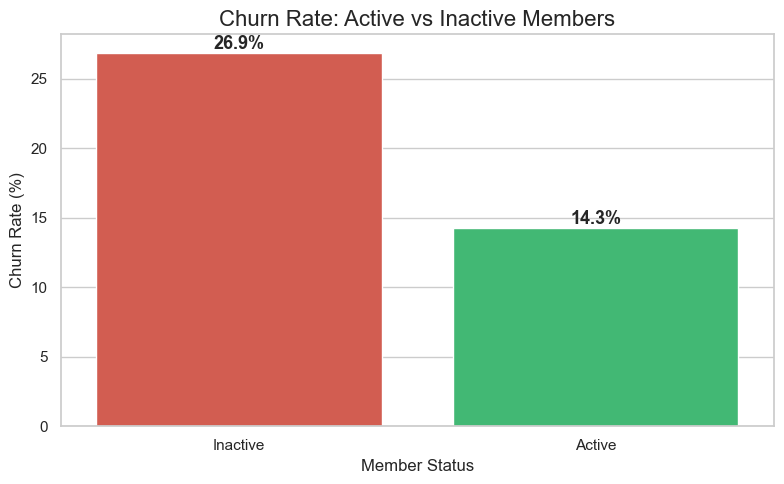

 Cell 7 complete — Churn by Active Member Status


In [10]:
# CELL 7 — CHURN BY ACTIVE MEMBER STATUS
# IsActiveMember = does the customer actively use the bank?
# Banking equivalent of TechSupport in Telco
# Logic: engaged customers are less likely to leave
# ============================================================
 
active_churn = df.groupby('IsActiveMember')['Churn_Binary'].mean() * 100
active_churn = active_churn.reset_index()
active_churn.columns = ['IsActiveMember', 'Churn_Rate']
active_churn['Status'] = active_churn['IsActiveMember'].map({1: 'Active', 0: 'Inactive'})
 
print("--- CHURN RATE BY ACTIVE MEMBER STATUS ---")
print(active_churn)
 
plt.figure(figsize=(8, 5))
bars = sns.barplot(data=active_churn, x='Status', y='Churn_Rate',
                   hue='Status',
                   palette={'Active': '#2ecc71', 'Inactive': '#e74c3c'},
                   legend=False)
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=13, fontweight='bold')
 
plt.title('Churn Rate: Active vs Inactive Members', fontsize=16)
plt.xlabel('Member Status')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_06_churn_by_active_member.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cell 7 complete — Churn by Active Member Status")

**Active Member Status:
Inactive members churn at 26.9% vs active members at 14.3%. Engagement protects against churn ,exactly the same pattern as Telco's tech support finding.**

--- CHURN RATE BY GENDER ---
   Gender  Churn_Rate
0  Female   25.071539
1    Male   16.455928


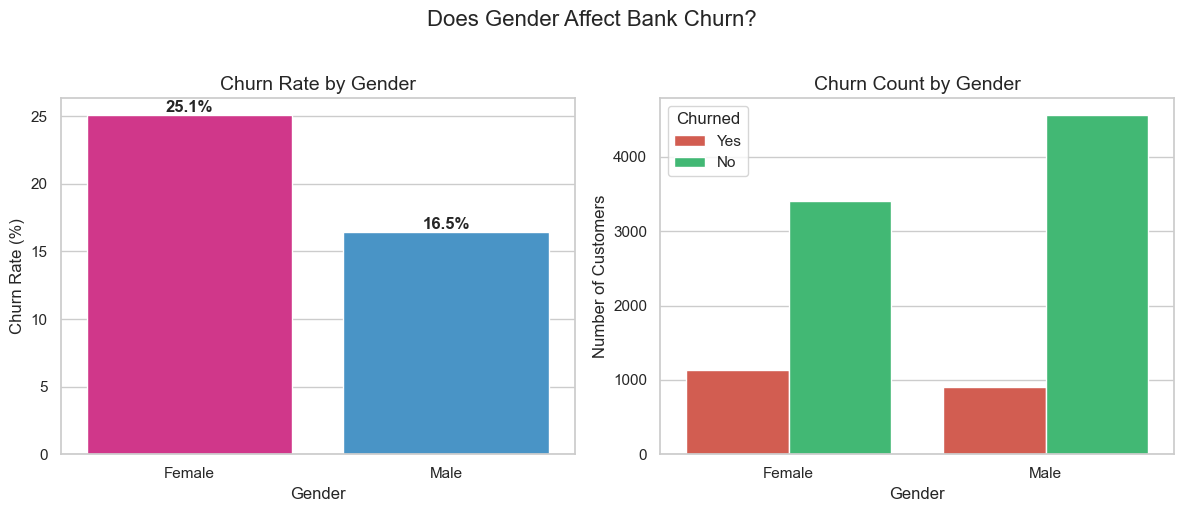

Cell 8 complete — Churn by Gender


In [11]:
# CELL 8 — CHURN BY GENDER
# Does gender affect bank churn?
# In telecom gender had almost no effect — is banking different?
# ============================================================
 
gender_churn = df.groupby('Gender')['Churn_Binary'].mean() * 100
gender_churn = gender_churn.reset_index()
gender_churn.columns = ['Gender', 'Churn_Rate']
 
print("--- CHURN RATE BY GENDER ---")
print(gender_churn)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
bars = sns.barplot(data=gender_churn, x='Gender', y='Churn_Rate',
                   hue='Gender',
                   palette={'Male': '#3498db', 'Female': '#e91e8c'},
                   legend=False, ax=axes[0])
axes[0].set_title('Churn Rate by Gender', fontsize=14)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Churn Rate (%)')
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')
 
sns.countplot(data=df, x='Gender', hue='Churn',
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              ax=axes[1])
axes[1].set_title('Churn Count by Gender', fontsize=14)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Churned')
 
plt.suptitle('Does Gender Affect Bank Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_07_churn_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 8 complete — Churn by Gender")

**Gender:
Females churn at 25.1% vs males at 16.5% — a meaningful difference. This is completely opposite to Telco where gender had almost no effect. Banking has a genuine gender gap in churn.**

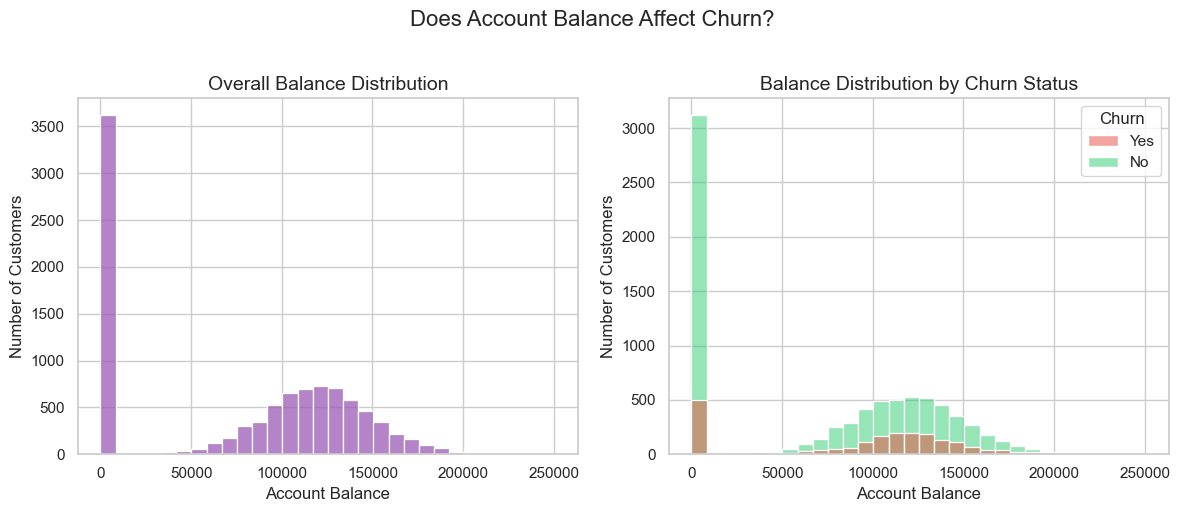

Cell 9 complete — Balance Distribution


In [12]:
# CELL 9 — BALANCE DISTRIBUTION
# Does account balance affect churn?
# Customers with zero balance may be disengaged
# High balance customers may have more to lose by leaving
# ============================================================
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Chart 1 — Overall balance distribution
sns.histplot(data=df, x='Balance', bins=30,
             color='#9b59b6', ax=axes[0])
axes[0].set_title('Overall Balance Distribution', fontsize=14)
axes[0].set_xlabel('Account Balance')
axes[0].set_ylabel('Number of Customers')
 
# Chart 2 — Balance by churn status
sns.histplot(data=df, x='Balance', hue='Churn',
             bins=30, palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
             ax=axes[1])
axes[1].set_title('Balance Distribution by Churn Status', fontsize=14)
axes[1].set_xlabel('Account Balance')
axes[1].set_ylabel('Number of Customers')
 
plt.suptitle('Does Account Balance Affect Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_08_balance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 9 complete — Balance Distribution")


**Balance Distribution
The huge spike at zero shows ~3,500 customers have no balance , almost all green (stayed). Customers with balances between $100k-$150k show the most red, higher balance customers are actually more likely to leave, possibly because they have more options.**

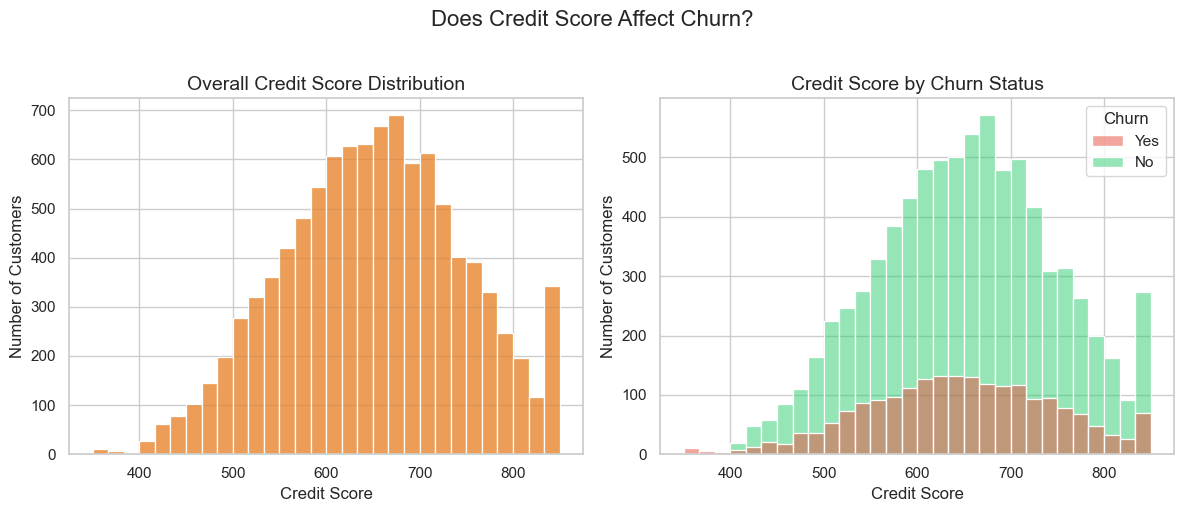

Cell 10 complete — Credit Score Distribution


In [13]:
# CELL 10 — CREDIT SCORE DISTRIBUTION
# Does credit score affect churn?
# Lower credit score = financial stress = more likely to leave?
# Unique to banking — no equivalent in Telco
# ============================================================
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Chart 1 — Overall credit score distribution
sns.histplot(data=df, x='CreditScore', bins=30,
             color='#e67e22', ax=axes[0])
axes[0].set_title('Overall Credit Score Distribution', fontsize=14)
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Number of Customers')
 
# Chart 2 — Credit score by churn
sns.histplot(data=df, x='CreditScore', hue='Churn',
             bins=30, palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
             ax=axes[1])
axes[1].set_title('Credit Score by Churn Status', fontsize=14)
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Number of Customers')
 
plt.suptitle('Does Credit Score Affect Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_09_credit_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 10 complete — Credit Score Distribution")

**Credit Score:
Credit score distributions for churned vs stayed customers look almost identical. Credit score does not meaningfully predict churn. The heatmap confirms this with a correlation of just -0.03.**

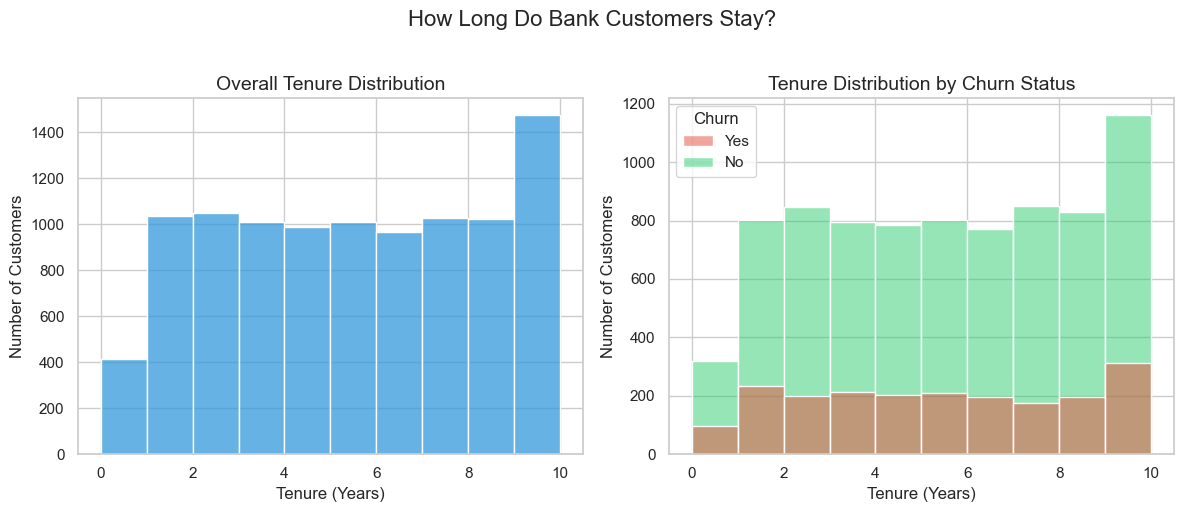

Cell 11 complete — Tenure Distribution


In [14]:
# CELL 11 — TENURE DISTRIBUTION
# How long have customers been with the bank?
# Compare with Telco — is the danger zone the same?
# In Telco new customers churned most — is banking the same?
# ============================================================
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
sns.histplot(data=df, x='Tenure', bins=10,
             color='#3498db', ax=axes[0])
axes[0].set_title('Overall Tenure Distribution', fontsize=14)
axes[0].set_xlabel('Tenure (Years)')
axes[0].set_ylabel('Number of Customers')
 
sns.histplot(data=df, x='Tenure', hue='Churn',
             bins=10, palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
             ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn Status', fontsize=14)
axes[1].set_xlabel('Tenure (Years)')
axes[1].set_ylabel('Number of Customers')
 
plt.suptitle('How Long Do Bank Customers Stay?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_10_tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 11 complete — Tenure Distribution")
 
 

**Tenure Distribution:
Unlike Telco where new customers churned heavily, bank churn is evenly spread across all tenure years. There is no clear danger zone , customers leave at similar rates whether they have been with the bank 1 year or 9 years.**

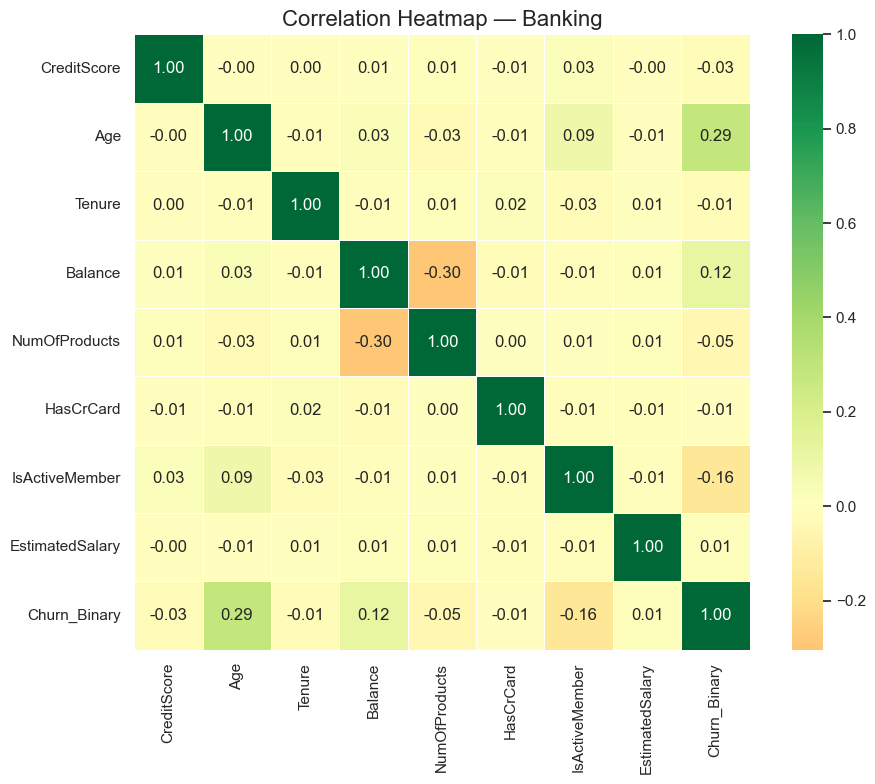

Cell 12 complete — Correlation Heatmap


In [15]:
#CELL 12 — CORRELATION HEATMAP
# Which numeric variables are most related to churn?
# Compare with Telco heatmap — same patterns or different?
# ============================================================
 
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = df[numeric_cols].corr()
 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)
 
plt.title('Correlation Heatmap — Banking', fontsize=16)
plt.tight_layout()
plt.savefig(project_path + 'bank_eda_11_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 12 complete — Correlation Heatmap")
 
 

**Correlation Heatmap — Key Numbers:
VariableCorrelation with ChurnAge+0.29 — strongest predictor , IsActiveMember-0.16 — engagement protects , Balance+0.12 — higher balance = more churn , NumOfProducts-0.05 — weak , CreditScore-0.03 — almost zeroTenure , -0.01 — no relationship.**

In [16]:
# CELL 13 — TYPICAL CHURNER PROFILE
# Who is the typical bank customer who leaves?
# ============================================================
 
churned = df[df['Churn'] == 'Yes']
stayed = df[df['Churn'] == 'No']
 
print("=" * 55)
print("      TYPICAL BANK CHURNER PROFILE SUMMARY")
print("=" * 55)
print(f"{'Metric':<30} {'Churned':>10} {'Stayed':>10}")
print("-" * 55)
print(f"{'Total customers':<30} {len(churned):>10,} {len(stayed):>10,}")
print(f"{'Avg Age':<30} {churned['Age'].mean():>10.1f} {stayed['Age'].mean():>10.1f}")
print(f"{'Avg Tenure (years)':<30} {churned['Tenure'].mean():>10.1f} {stayed['Tenure'].mean():>10.1f}")
print(f"{'Avg Balance':<30} ${churned['Balance'].mean():>9,.0f} ${stayed['Balance'].mean():>9,.0f}")
print(f"{'Avg Credit Score':<30} {churned['CreditScore'].mean():>10.1f} {stayed['CreditScore'].mean():>10.1f}")
print(f"{'Avg Estimated Salary':<30} ${churned['EstimatedSalary'].mean():>9,.0f} ${stayed['EstimatedSalary'].mean():>9,.0f}")
print(f"{'Avg Num of Products':<30} {churned['NumOfProducts'].mean():>10.2f} {stayed['NumOfProducts'].mean():>10.2f}")
print(f"{'% Active Members':<30} {churned['IsActiveMember'].mean()*100:>9.1f}% {stayed['IsActiveMember'].mean()*100:>9.1f}%")
print(f"{'% Female':<30} {(churned['Gender']=='Female').mean()*100:>9.1f}% {(stayed['Gender']=='Female').mean()*100:>9.1f}%")
print(f"{'Most Common Geography':<30} {churned['Geography'].mode()[0]:>10} {stayed['Geography'].mode()[0]:>10}")
print("=" * 55)
print("\nCell 13 complete — Bank Churner Profile")
print("\nBANK EDA COMPLETE!")

      TYPICAL BANK CHURNER PROFILE SUMMARY
Metric                            Churned     Stayed
-------------------------------------------------------
Total customers                     2,037      7,963
Avg Age                              44.8       37.4
Avg Tenure (years)                    4.9        5.0
Avg Balance                    $   91,109 $   72,745
Avg Credit Score                    645.4      651.9
Avg Estimated Salary           $  101,466 $   99,738
Avg Num of Products                  1.48       1.54
% Active Members                    36.1%      55.5%
% Female                            55.9%      42.7%
Most Common Geography             Germany     France

Cell 13 complete — Bank Churner Profile

BANK EDA COMPLETE!


**Typical Churner Profile:
The typical bank churner is older (avg 44.8 vs 37.4), has a higher balance ($91k vs $73k), is more likely female (55.9%), is inactive (only 36% active vs 55%), and most commonly from Germany. Completely different profile from the Telco churner.**